# ! Veri setinin indirilmesi için kaggleden de indirebiliriz yada "sklearn.dataset" içinde de var 

In [195]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("camnugent/california-housing-prices")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\canoz\.cache\kagglehub\datasets\camnugent\california-housing-prices\versions\1


### Load dataset and preprocessing 

In [196]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split ,GridSearchCV #train test split ile verileri ayırıyoruz  #hyperparameter tuning için GridSearchCV kullanıyoruz
from sklearn.preprocessing import StandardScaler #verimizi 0 ortalamalı bir veri setine dönüştürmek için kullanıyoruz standarlaştırma 
from sklearn.linear_model import LinearRegression, Ridge,Lasso,ElasticNet #linear regression modeli oluşturuyoruz
#RİDGE VE LASSO OVERFİTİNG ENGELLEMEK İÇİN #ELASTİCNET İSE RİDGE VE LASSO İÇİN FARKLI ORANLARDA KULLANBİLMEYE YARAR 

from sklearn.metrics import mean_squared_error,r2_score #modelin başarısını ölçmek için kullanıyoruz

from sklearn.datasets import fetch_california_housing #! verileri içe aktarıyoruz


import warnings #uyarıları engellemek için kullanıyoruz
warnings.filterwarnings("ignore")

#### load dataset

In [197]:
california =fetch_california_housing() #içeriğinde  features ve target olmak üzerer iki array var 

california

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [198]:
x=california.data #özellikler 
y=california.target #fiyatlar 

#### train test split

In [199]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)


#### scaler standrtlaştırma

In [200]:

scaler=StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)  #x_test için fit yazmayız 

### Lineer ridge lasso regresyon modelleri train hyper parameters tunning

##### Basit lineer regresyon

In [201]:
lin_reg=LinearRegression()
lin_reg.fit(x_train_scaled,y_train)

y_pred_lin=lin_reg.predict(x_test_scaled)
y_pred_lin

array([1.57674864, 1.25432929, 1.97219411, ..., 1.03827708, 2.43899251,
       1.44014286], shape=(4128,))

In [202]:
y_test

array([1.576, 1.431, 1.118, ..., 1.052, 3.448, 1.149], shape=(4128,))

Lİneer Model performans değerlendirme mse ve r2

In [203]:
mse_lin=mean_squared_error(y_test,y_pred_lin)
r2_lin=r2_score(y_test,y_pred_lin)
print("lineer Model MSE Skoru : ",mse_lin)
print("lineer Model R2 Skoru : ",r2_lin)


lineer Model MSE Skoru :  0.5224747243821511
lineer Model R2 Skoru :  0.6046844156981557


##### Ridge L2 Regression 

In [204]:
ridge_params={
"alpha":[0.1,1,10,100,1000]
}
ridge=Ridge()
ridge_grid =GridSearchCV(ridge,ridge_params ,cv=5,verbose=1)
ridge_grid.fit(x_train_scaled,y_train)
y_pred_ridge=ridge_grid.predict(x_test_scaled)





Fitting 5 folds for each of 5 candidates, totalling 25 fits


Ridge model Performans değerlendirmesi MSE ,R2

In [205]:
mse_ridge=mean_squared_error(y_test,y_pred_ridge)
r2_ridge=r2_score(y_test,y_pred_ridge)
print("Ridge Model MSE Skoru : ",mse_ridge)
print("Ridge Model R2 Skoru : ",r2_ridge)
print(f"Ridge Model Best Alpha : {ridge_grid.best_params_}")



Ridge Model MSE Skoru :  0.5226065689772804
Ridge Model R2 Skoru :  0.6045846592492248
Ridge Model Best Alpha : {'alpha': 10}


##### Lasso L1 Regresyon

In [206]:
lasso_params={
"alpha":[0.1,1,10,100,1000]
}
lasso=Lasso(max_iter=10000)
lasso_grid =GridSearchCV(lasso,lasso_params ,cv=5 )
lasso_grid.fit(x_train_scaled,y_train)

y_pred_lasso=lasso_grid.predict(x_test_scaled)

Lasso model Performans değerlendirmesi MSE ,R2

In [207]:
mse_lasso=mean_squared_error(y_test,y_pred_lasso)
r2_lasso=r2_score(y_test,y_pred_lasso)
print("lasso Model MSE Skoru : ",mse_lasso)
print("lasso Model R2 Skoru : ",r2_lasso)
print(f"lasso Model Best Alpha : {lasso_grid.best_params_}")

lasso Model MSE Skoru :  0.6785703041322375
lasso Model R2 Skoru :  0.4865791515845439
lasso Model Best Alpha : {'alpha': 0.1}


### ElasticNet Tranning and Hyperparameter Tuning

 #?!  ElasticNet de (l1 ve l2) lasso ve ridge modelleri birlikte kullanılır 
#?! farklı ağırlıklarda kullanılarak model kurulur daha iyi olabilir 

In [208]:
elastic_params={"alpha": [0.1,1,10],"l1_ratio": [0.1,0.5,0.8]} #0.2 l1 -- 0.8 l2 olur ------- 0.5 0.5 l1 ve l2 sonuçları ağırlıkla eşit olur.

elastic=ElasticNet(max_iter=10000)
elastic_grid=GridSearchCV(elastic,elastic_params,cv=5)
elastic_grid.fit(x_train_scaled,y_train)


,estimator,ElasticNet(max_iter=10000)
,param_grid,"{'alpha': [0.1, 1, ...], 'l1_ratio': [0.1, 0.5, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,0.1


Lasso model Performans değerlendirmesi MSE ,R2

In [209]:
y_pred_elastic=elastic_grid.predict(x_test_scaled) #elasticnet tahmini x_test'e göre gerçekleştirdik tahmin edilen ev fiyat tahminleri 

mse_elastic=mean_squared_error(y_test,y_pred_elastic)
r2_elastic=r2_score(y_test,y_pred_elastic)
print("elastic Model MSE Skoru : ",mse_elastic)
print("elastic Model R2 Skoru : ",r2_elastic)
print(f"elastic Model Best Params : {elastic_grid.best_params_}")

elastic Model MSE Skoru :  0.5873393534769829
elastic Model R2 Skoru :  0.5556064458854177
elastic Model Best Params : {'alpha': 0.1, 'l1_ratio': 0.1}


### Model comparision (model karşılaştırma) 

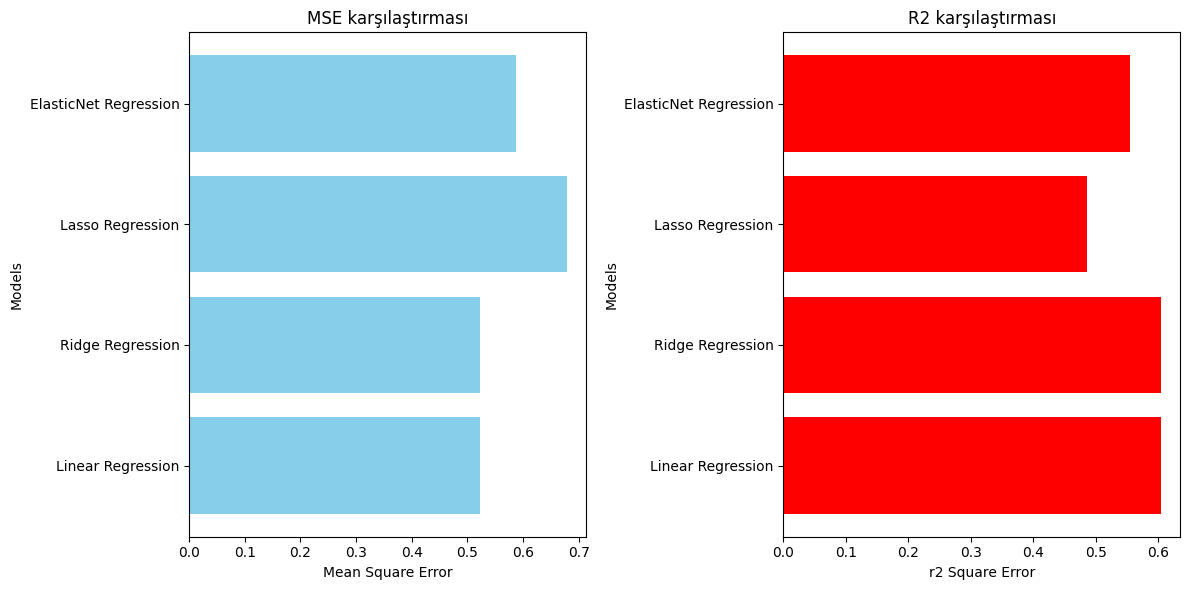

In [210]:
models=["Linear Regression","Ridge Regression","Lasso Regression", "ElasticNet Regression"] #karşılaşılacak modellerin isimlerini tutan listeyi oluşturduk

mses=[mse_lin ,mse_ridge,mse_lasso,mse_elastic] #mses mse ler listesi oluşturuldu
r2s=[r2_lin,r2_ridge,r2_lasso,r2_elastic] #r2s r2 ler listesi oluşturuldu

#MSE ÇİZDİRME

plt.figure(figsize=(12,6)) #figure boyutu belirlendi

plt.subplot(1,2,1) # 1 satır 2 tundan oluşacak 1.stunu çiziyoruz 
plt.barh(models,mses,color="skyblue") #barh fonksiyonu ile çizim yapılacak  horizontal olarak bar çizdiriliyor
plt.xlabel("Mean Square Error") #x ekseninin ismi
plt.ylabel("Models") #y ekseninin ismi
plt.title("MSE karşılaştırması") #başlık


# R2S ÇİZDİRME

plt.subplot(1,2,2) #! 1 satır 2 tundan oluşacak 2.stunu çiziyoruz 
plt.barh(models,r2s,color="red") #barh fonksiyonu ile çizim yapılacak  horizontal olarak bar çizdiriliyor
plt.xlabel("r2 Square Error") #x ekseninin ismi
plt.ylabel("Models") #y ekseninin ismi
plt.title("R2 karşılaştırması") #başlık

plt.tight_layout() #görüntülerin yerlerini düzeltir
plt.show() #görselleştirme
